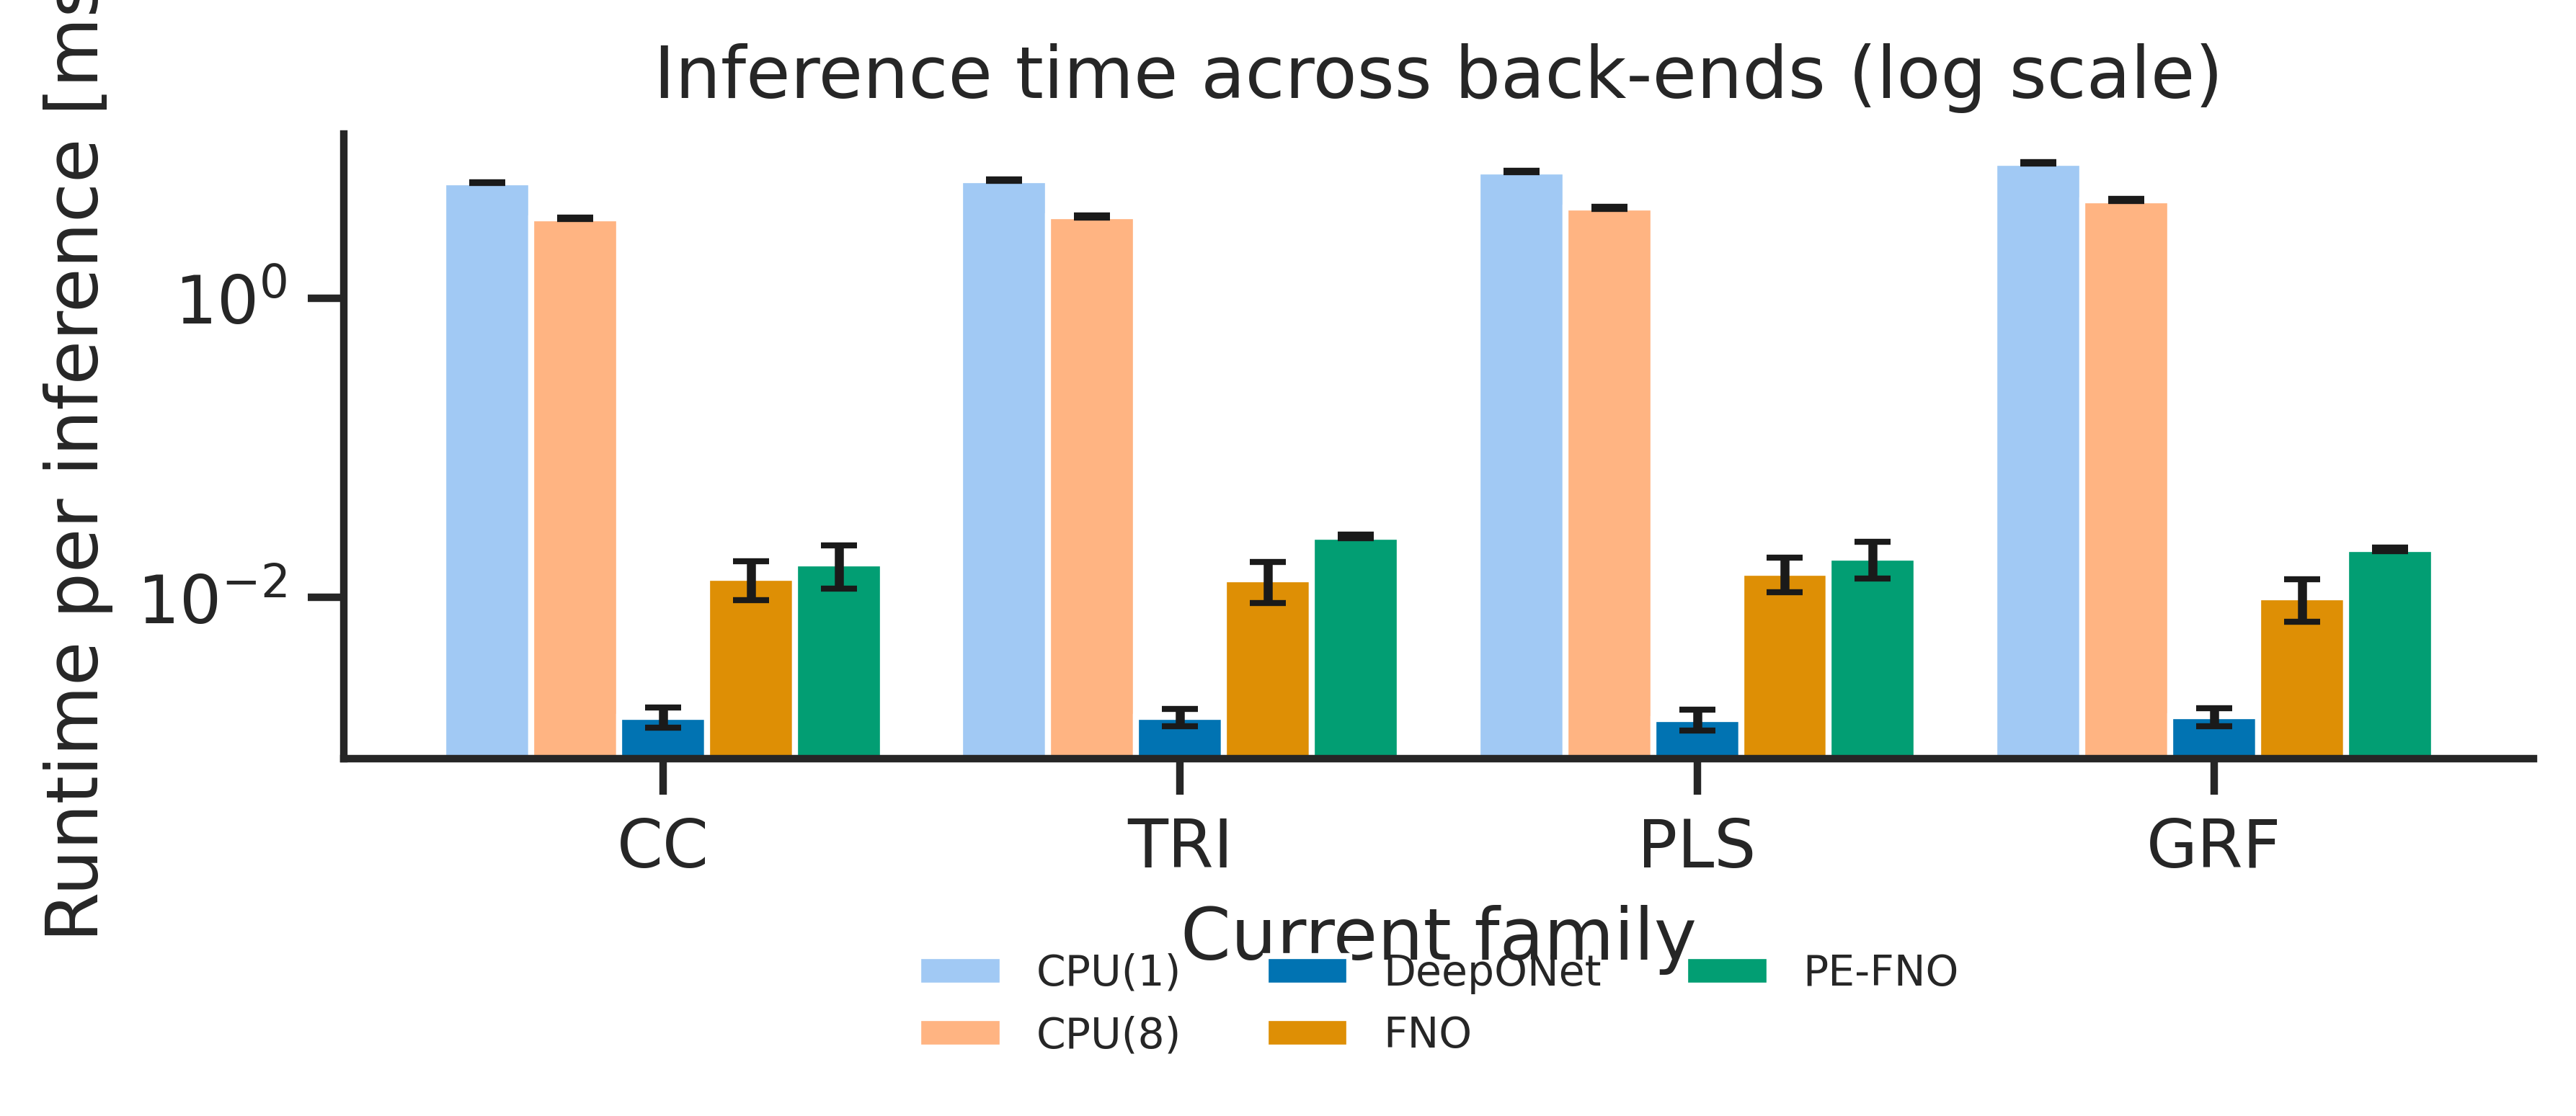

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── DATA ───────────────────────────────────────────────────────────────────
families = ["CC", "TRI", "PLS", "GRF"]

backends = {
    "CPU(1)"  : (np.array([5.9, 6.1, 7.0, 8.0]),  np.array([0.05, 0.06, 0.07, 0.08])),
    "CPU(8)"  : (np.array([3.4, 3.5, 4.0, 4.5]),  np.array([0.04, 0.05, 0.06, 0.07])),
    "DeepONet": (np.array([0.00160, 0.00160, 0.00154, 0.00161]),
                 np.array([0.00025, 0.00021, 0.00024, 0.00022])),
    "FNO"     : (np.array([0.0136, 0.0133, 0.0147, 0.0101]),
                 np.array([0.00394, 0.00407, 0.00384, 0.00321])),
    "PE-FNO"  : (np.array([0.0169, 0.0256, 0.0185, 0.0210]),
                 np.array([0.00547, 0.00066, 0.00506, 0.00051])),
}

cpu_keys = [k for k in backends if k.startswith("CPU")]
ml_keys  = [k for k in backends if not k.startswith("CPU")]

colors_cpu = sns.color_palette("pastel", len(cpu_keys))
colors_ml  = sns.color_palette("colorblind", len(ml_keys))

colour_map = {k: c for k, c in zip(cpu_keys+ml_keys, colors_cpu+colors_ml)}

# ── PLOT ───────────────────────────────────────────────────────────────────
sns.set_theme(style="ticks")
plt.rcParams.update({"font.size": 8})
fig, ax = plt.subplots(figsize=(6.0, 2.8), dpi=600)

n_back   = len(backends)
x        = np.arange(len(families))
width    = 0.85 / n_back
offsets  = np.linspace(-0.85/2 + width/2, 0.85/2 - width/2, n_back)

for off, name in zip(offsets, backends.keys()):
    mean, std = backends[name]
    ax.bar(x + off, mean, yerr=std, width=width,
           label=name, capsize=3, color=colour_map[name])

ax.set_xticks(x)
ax.set_xticklabels(families)
ax.set_yscale("log")
ax.set_ylabel("Runtime per inference [ms]")
ax.set_xlabel("Current family")
ax.set_title("Inference time across back-ends (log scale)")

# Legend below x-axis
ax.legend(frameon=False, fontsize=7, ncol=3,
          bbox_to_anchor=(0.5, -0.25), loc="upper center")

sns.despine()
fig.tight_layout()
plt.show()


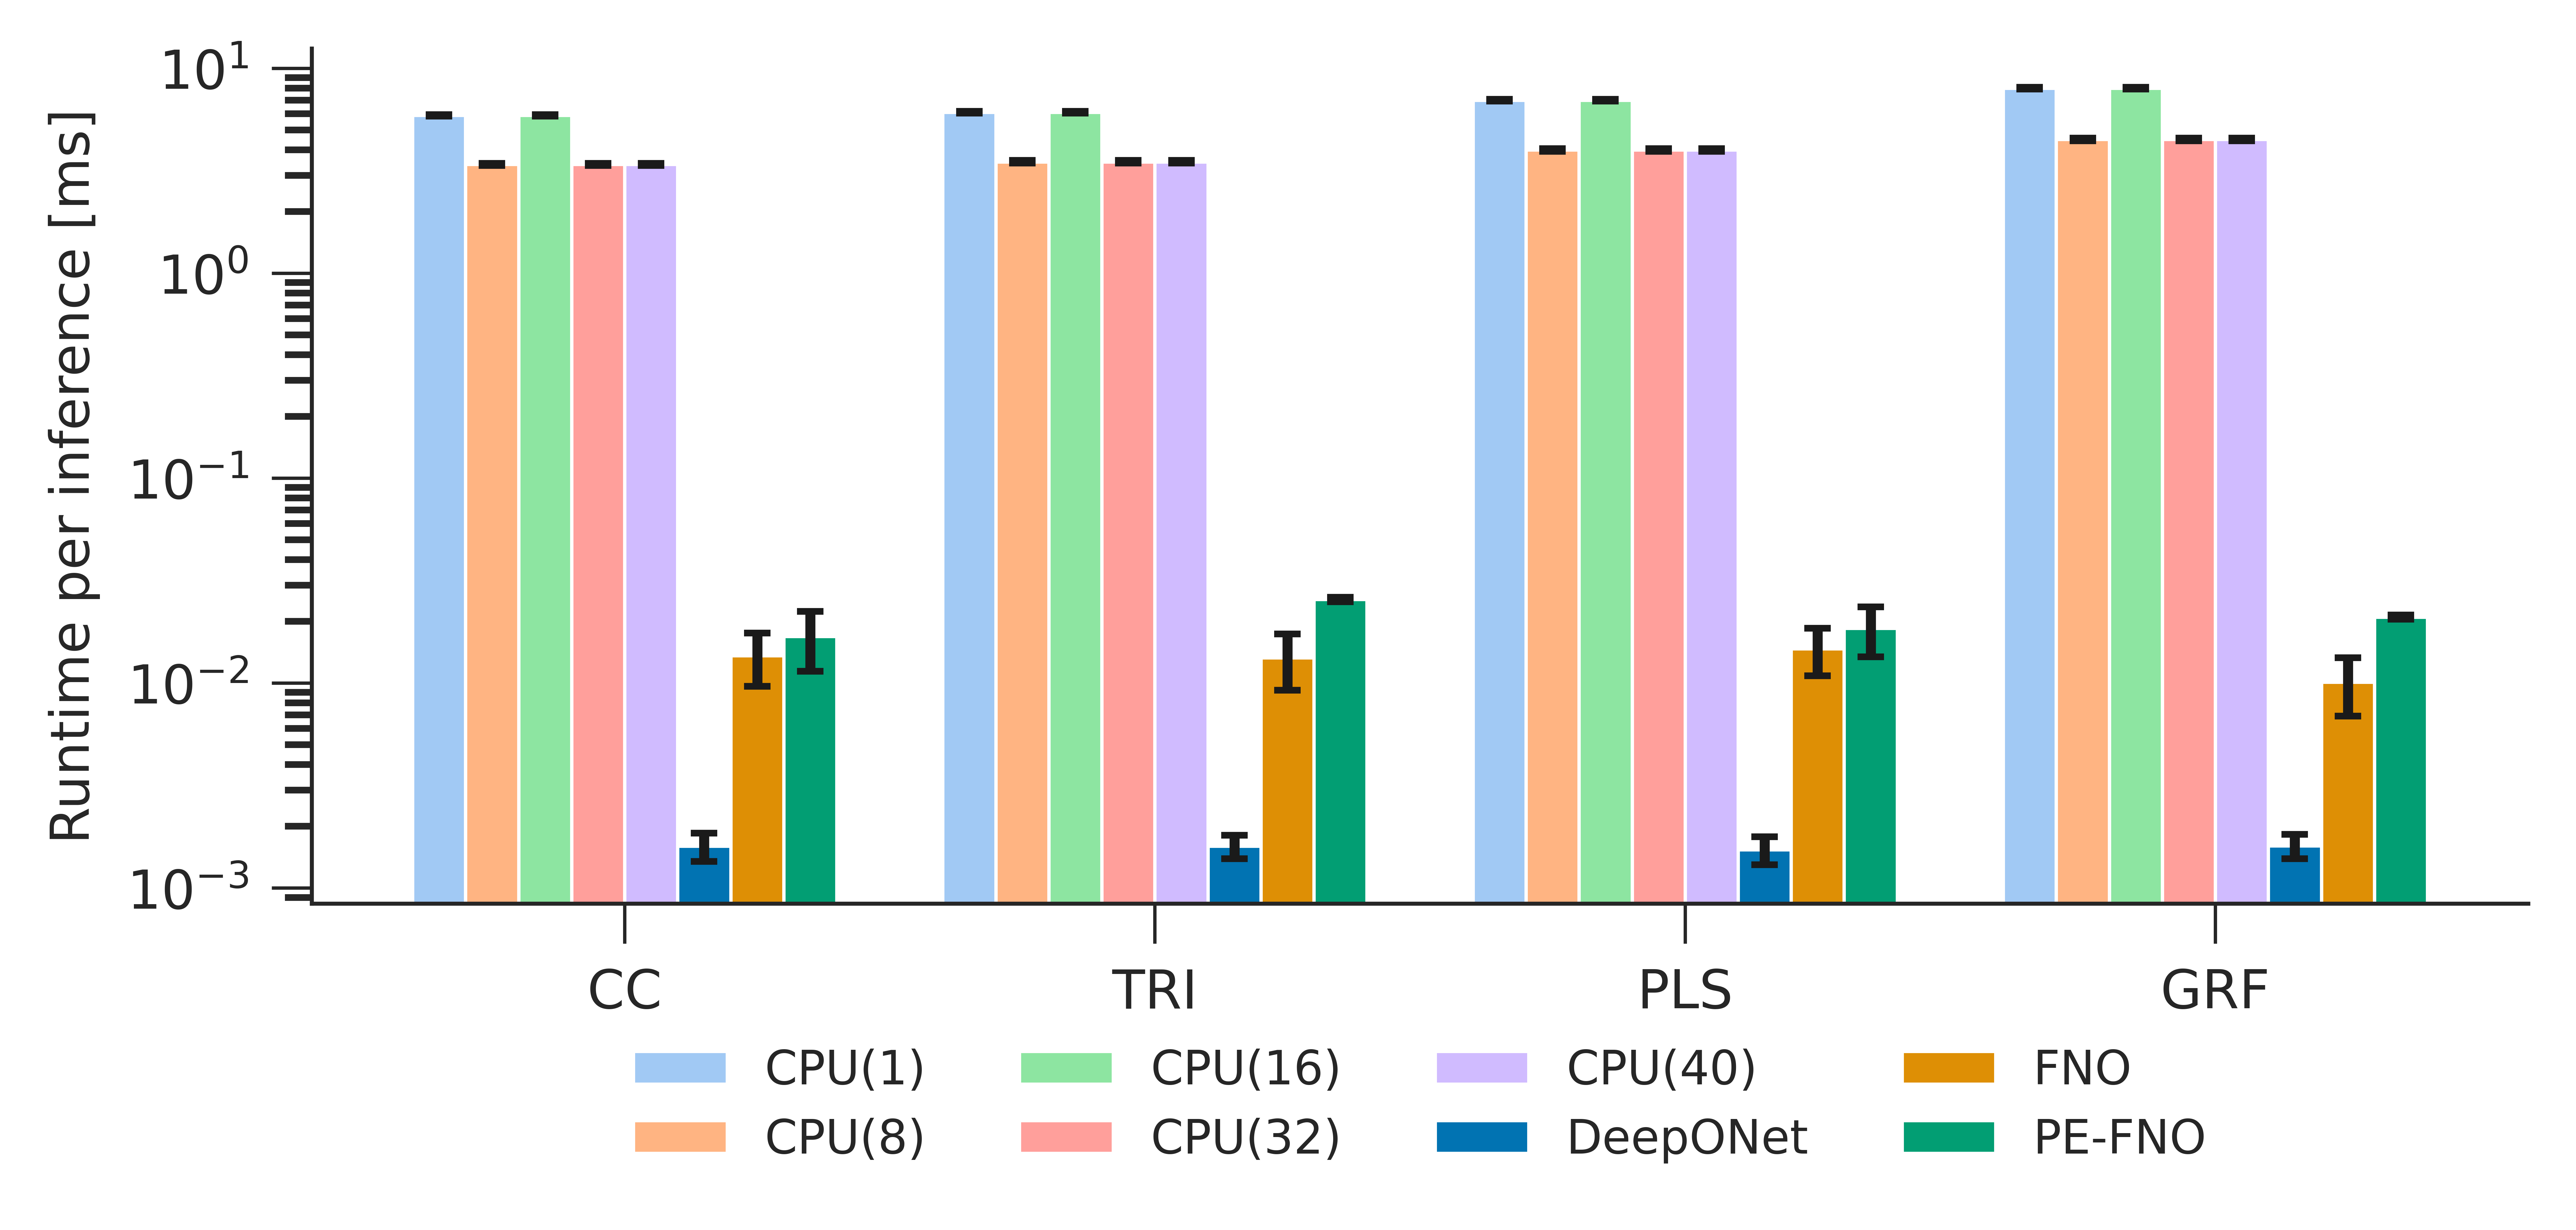

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── DATA -------------------------------------------------------------------
families = ["CC", "TRI", "PLS", "GRF"]

backends = {
    "CPU(1)" : (np.array([24.865474, 24.909574, 24.843610, 24.907420]),
                np.array([0.265755, 0.252998, 0.304807, 0.267395])),
    "CPU(2)" : (np.array([12.869151, 12.874171, 12.889260, 12.834041]),
                np.array([0.152636, 0.118057, 0.157338, 0.135969])),
    "CPU(4)" : (np.array([7.118515, 7.007278, 7.032914, 7.104425]),
                np.array([0.124034, 0.144009, 0.126052, 0.083744])),
    "CPU(8)" : (np.array([4.710162,  4.965254,  4.910845,  4.901369]),
                np.array([0.294985, 0.155364, 0.257280, 0.324471])),
    "CPU(16)": (np.array([4.070603, 4.097761, 4.176765, 4.033633]),
                np.array([0.551936, 0.526227, 0.585039, 0.510827])),

    "DeepONet": (np.array([0.00160, 0.00160, 0.00154, 0.00161]),
                 np.array([0.00025, 0.00021, 0.00024, 0.00022])),
    "FNO"     : (np.array([0.0136, 0.0133, 0.0147, 0.0101]),
                 np.array([0.00394, 0.00407, 0.00384, 0.00321])),
    "PE-FNO"  : (np.array([0.0169, 0.0256, 0.0185, 0.0210]),
                 np.array([0.00547, 0.00066, 0.00506, 0.00051])),
}

cpu_keys = [k for k in backends if k.startswith("CPU")]
ml_keys  = [k for k in backends if not k.startswith("CPU")]

colors_cpu = sns.color_palette("pastel", len(cpu_keys))
colors_ml  = sns.color_palette("colorblind", len(ml_keys))
colour_map = {k: c for k, c in zip(cpu_keys + ml_keys, colors_cpu + colors_ml)}

# ── PLOT STYLE -------------------------------------------------------------
sns.set_theme(style="ticks")
plt.rcParams.update({
    "axes.labelsize":   8,
    "axes.titlesize":   8,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "legend.fontsize":  7,
    "axes.linewidth":   0.6,
    "xtick.major.width":0.5,
    "ytick.major.width":0.5,
})

# width = 90 mm, choose height ~45 mm
fig_w, fig_h = 140/25.4, 70/25.4   # inches
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=1600)

n_back   = len(backends)
x        = np.arange(len(families))
width    = 0.8 / n_back
offsets  = np.linspace(-0.8/2 + width/2, 0.8/2 - width/2, n_back)

for off, name in zip(offsets, backends.keys()):
    mean, std = backends[name]
    ax.bar(x + off, mean, yerr=std, width=width,
           label=name, capsize=2, lw=0.5, color=colour_map[name])

ax.set_xticks(x)
ax.set_xticklabels(families)
ax.set_yscale("log")
ax.set_ylabel("Runtime per inference [ms]")

# legend below axis with gap
ax.legend(frameon=False, ncol=n_back/2,
          bbox_to_anchor=(0.5, -0.12), loc="upper center")

sns.despine()
fig.tight_layout()
fig.savefig("speed_benchmark_plot.svg", bbox_inches="tight")
plt.show()
